# Steel DPP Regression Demo 


> The data is synthetic.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)


## 1. Generate mock Steel DPP data

The generated fields represent useful DPP categories such as:
- product type and steel grade;
- production route;
- recycled content;
- renewable energy;
- energy consumption;
- chemical composition;
- mechanical properties;
- batch-level traceability;
- carbon footprint.


In [3]:
rng = np.random.default_rng(42)
n = 10000

product_types = np.array([
    "Hot Rolled Coil",
    "Wire Rod",
    "Galvanised Coil",
    "Electrical Steel",
    "Stainless Steel"
])

steel_grades = np.array([
    "S235JR",
    "S355JR",
    "DX51D",
    "304",
    "M270-35A"
])

routes = np.array(["EAF", "BF-BOF"])
countries = np.array(["Germany", "France", "Italy", "Spain", "Belgium"])

product_type = rng.choice(
    product_types,
    n,
    p=[0.30, 0.18, 0.22, 0.15, 0.15]
)

steel_grade = rng.choice(steel_grades, n)
technology_route = rng.choice(routes, n, p=[0.55, 0.45])
country_of_origin = rng.choice(countries, n)

recycled_content_pct = np.where(
    technology_route == "EAF",
    rng.normal(78, 10, n),
    rng.normal(24, 9, n)
)
recycled_content_pct = np.clip(recycled_content_pct, 5, 98)

renewable_energy_pct = rng.uniform(5, 90, n)

energy_consumption_kwh_per_tonne = np.where(
    technology_route == "EAF",
    rng.normal(650, 80, n),
    rng.normal(1850, 170, n)
)
energy_consumption_kwh_per_tonne = np.clip(
    energy_consumption_kwh_per_tonne,
    400,
    2300
)

scrap_quality_score = rng.uniform(55, 98, n)
batch_weight_tonnes = rng.uniform(8, 35, n)
thickness_mm = rng.uniform(0.5, 25, n)

carbon_pct = np.clip(rng.normal(0.18, 0.07, n), 0.02, 0.65)
manganese_pct = np.clip(rng.normal(1.15, 0.35, n), 0.25, 2.20)

chromium_pct = np.where(
    product_type == "Stainless Steel",
    rng.normal(18.0, 1.2, n),
    np.clip(rng.normal(0.35, 0.20, n), 0, 1.5)
)
chromium_pct = np.clip(chromium_pct, 0, 22)

yield_strength_mpa = (
    180
    + 130 * carbon_pct
    + 45 * manganese_pct
    + 3.5 * chromium_pct
    + rng.normal(0, 25, n)
)
yield_strength_mpa = np.clip(yield_strength_mpa, 170, 750)

tensile_strength_mpa = (
    yield_strength_mpa
    + rng.normal(150, 30, n)
)
tensile_strength_mpa = np.clip(tensile_strength_mpa, 300, 950)

route_effect = np.where(
    technology_route == "BF-BOF",
    520,
    90
)

product_effect_map = {
    "Hot Rolled Coil": 40,
    "Wire Rod": 55,
    "Galvanised Coil": 130,
    "Electrical Steel": 170,
    "Stainless Steel": 360
}

product_effect = np.array([
    product_effect_map[item]
    for item in product_type
])

carbon_footprint = (
    0.55 * energy_consumption_kwh_per_tonne
    + route_effect
    + product_effect
    - 4.4 * recycled_content_pct
    - 2.2 * renewable_energy_pct
    - 1.1 * scrap_quality_score
    + 0.9 * chromium_pct
    + rng.normal(0, 75, n)
)

carbon_footprint = np.clip(carbon_footprint, 120, 2600)

df = pd.DataFrame({
    "batch_id": [f"BATCH-{i:04d}" for i in range(1, n + 1)],
    "product_type": product_type,
    "steel_grade": steel_grade,
    "technology_route": technology_route,
    "country_of_origin": country_of_origin,
    "batch_weight_tonnes": np.round(batch_weight_tonnes, 2),
    "thickness_mm": np.round(thickness_mm, 2),
    "recycled_content_pct": np.round(recycled_content_pct, 2),
    "renewable_energy_pct": np.round(renewable_energy_pct, 2),
    "energy_consumption_kwh_per_tonne": np.round(
        energy_consumption_kwh_per_tonne, 1
    ),
    "scrap_quality_score": np.round(scrap_quality_score, 2),
    "carbon_pct": np.round(carbon_pct, 3),
    "manganese_pct": np.round(manganese_pct, 3),
    "chromium_pct": np.round(chromium_pct, 3),
    "yield_strength_mpa": np.round(yield_strength_mpa, 1),
    "tensile_strength_mpa": np.round(tensile_strength_mpa, 1),
    "carbon_footprint_kgco2e_per_tonne": np.round(
        carbon_footprint, 1
    )
})

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (10000, 17)


,batch_id,product_type,steel_grade,technology_route,country_of_origin,batch_weight_tonnes,thickness_mm,recycled_content_pct,renewable_energy_pct,energy_consumption_kwh_per_tonne,scrap_quality_score,carbon_pct,manganese_pct,chromium_pct,yield_strength_mpa,tensile_strength_mpa,carbon_footprint_kgco2e_per_tonne
0,BATCH-0001,Electrical Steel,S235JR,EAF,Germany,26.98,11.80,59.02,82.17,492.4,55.94,0.199,1.011,0.052,252.4,423.8,120.0
1,BATCH-0002,Wire Rod,304,EAF,Belgium,16.48,17.10,69.54,44.21,577.2,83.88,0.231,1.360,0.048,253.1,355.7,120.0
2,BATCH-0003,Stainless Steel,S355JR,EAF,Italy,21.73,10.58,68.06,33.20,610.3,87.04,0.206,0.859,19.317,327.8,453.0,315.5
3,BATCH-0004,Galvanised Coil,304,BF-BOF,Belgium,11.45,10.07,33.34,23.38,1796.1,64.59,0.210,0.827,0.449,236.4,381.3,1352.1
4,BATCH-0005,Hot Rolled Coil,DX51D,EAF,Italy,33.13,22.32,81.00,32.47,495.6,88.04,0.128,1.122,0.472,247.2,380.1,120.0


In [4]:
# Save a copy of the generated mock data
df.to_csv("steel_dpp_mock_data_clean.csv", index=False)
print("Saved as steel_dpp_mock_data_clean.csv")


Saved as steel_dpp_mock_data_clean.csv


## 2. Data quality check


In [13]:
print("Missing values:")
display(df.isna().sum())

numeric_values = df.select_dtypes(include=np.number)

print("Infinite values:",
      np.isinf(numeric_values.to_numpy()).sum())

display(df.describe().T)


Missing values:


batch_id                             0
product_type                         0
steel_grade                          0
technology_route                     0
country_of_origin                    0
batch_weight_tonnes                  0
thickness_mm                         0
recycled_content_pct                 0
renewable_energy_pct                 0
energy_consumption_kwh_per_tonne     0
scrap_quality_score                  0
carbon_pct                           0
manganese_pct                        0
chromium_pct                         0
yield_strength_mpa                   0
tensile_strength_mpa                 0
carbon_footprint_kgco2e_per_tonne    0
dtype: int64

Infinite values: 0


,count,mean,std,min,25%,50%,75%,max
batch_weight_tonnes,10000.0,21.565430,7.847958,8.00,14.8100,21.665,28.47000,35.000
thickness_mm,10000.0,12.757338,7.045671,0.50,6.6300,12.730,18.91250,25.000
recycled_content_pct,10000.0,53.398093,28.430665,5.00,25.0500,64.060,78.95000,98.000
renewable_energy_pct,10000.0,47.545216,24.579164,5.00,26.2975,47.290,68.88000,89.990
energy_consumption_kwh_per_tonne,10000.0,1192.546790,609.054902,400.00,642.1750,758.950,1823.70000,2300.000
scrap_quality_score,10000.0,76.389126,12.408006,55.00,65.6175,76.455,86.94000,98.000
carbon_pct,10000.0,0.180710,0.069875,0.02,0.1330,0.180,0.22800,0.446
manganese_pct,10000.0,1.149057,0.347999,0.25,0.9130,1.147,1.38225,2.200
chromium_pct,10000.0,2.947641,6.260899,0.00,0.2390,0.392,0.58400,21.791
yield_strength_mpa,10000.0,265.484780,37.721707,170.00,239.5000,262.800,287.92500,426.000


## 3. Select features and prediction target

The target is:

`carbon_footprint_kgco2e_per_tonne`


### What are the inputs and the target?

The **features** are the pieces of information given to the model, such as the production route, recycled content, renewable-energy percentage, and energy consumption.

The **target** is the value that the model must learn to predict:

- `carbon_footprint_kgco2e_per_tonne`
- Unit: **kilograms of CO₂ equivalent per tonne of steel**
- Example: a value of **140** means that producing one tonne of this steel is associated with approximately **140 kg CO₂e** in this synthetic dataset.

The model learns relationships between the input values and the known carbon footprint in the training data. It then applies those learned relationships to new batches.


In [12]:
target = "carbon_footprint_kgco2e_per_tonne"

features = [
    "product_type",
    "steel_grade",
    "technology_route",
    "country_of_origin",
    "batch_weight_tonnes",
    "thickness_mm",
    "recycled_content_pct",
    "renewable_energy_pct",
    "energy_consumption_kwh_per_tonne",
    "scrap_quality_score",
    "carbon_pct",
    "manganese_pct",
    "chromium_pct",
    "yield_strength_mpa",
    "tensile_strength_mpa"
]

X = df[features].copy()
y = df[target].astype("float64").copy()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

for column in numeric_features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    ).astype("float64")

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['product_type', 'steel_grade', 'technology_route', 'country_of_origin']
Numeric features: ['batch_weight_tonnes', 'thickness_mm', 'recycled_content_pct', 'renewable_energy_pct', 'energy_consumption_kwh_per_tonne', 'scrap_quality_score', 'carbon_pct', 'manganese_pct', 'chromium_pct', 'yield_strength_mpa', 'tensile_strength_mpa']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 8000
Testing rows: 2000


## 4. Preprocessing

No manual matrix multiplication and no ordinary linear regression are used here.


### Why is preprocessing necessary?

The model receives two types of data:

- **Numerical values**, such as energy consumption and recycled-content percentage.
- **Categorical values**, such as `EAF`, `BF-BOF`, product type, and country.

Missing numerical values are replaced with the median. Missing categories are replaced with the most frequent category. Categorical text is converted into machine-readable columns using one-hot encoding.

This step does not improve sustainability by itself. It only prepares the DPP data so the regression models can process it correctly.


In [17]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created.")


Preprocessor created.


## 5. Random Forest Regression


### Why include Random Forest?

Random Forest builds many decision trees and averages their predictions. It is useful here because:

- it can learn non-linear relationships;
- it can handle interactions between variables;
- it does not assume that carbon footprint changes in a perfectly straight line;
- it provides direct feature-importance values.

It is used as a strong comparison model and as an easy way to explain which variables influence the predictions.


In [16]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest MAE:  {rf_mae:.2f} kg CO2e/t")
print(f"Random Forest RMSE: {rf_rmse:.2f} kg CO2e/t")
print(f"Random Forest R²:   {rf_r2:.3f}")


Random Forest MAE:  40.76 kg CO2e/t
Random Forest RMSE: 61.96 kg CO2e/t
Random Forest R²:   0.990


### How to read the Random Forest results

- **MAE = 40.76 kg CO₂e/t:** On average, the prediction differs from the actual synthetic value by about **40.76 kg CO₂e per tonne**.
- **RMSE = 61.96 kg CO₂e/t:** This also measures prediction error, but it gives a larger penalty to big mistakes. Lower is better.
- **R² = 0.990:** The model explains about **99.0% of the variation** in the synthetic carbon-footprint values. Closer to 1 is better.

The very high R² is expected because the mock target was generated from clear mathematical relationships. A real industrial dataset would usually be noisier and more difficult.


## 6. Gradient Boosting Regression


### Why choose HistGradientBoostingRegressor?

Gradient boosting builds a sequence of small decision trees. Each new tree focuses on correcting errors made by the previous trees. This makes it suitable for this demo because steel carbon footprint can depend on **non-linear combinations** of variables, for example:

- the production route together with energy consumption;
- renewable-energy percentage together with electricity use;
- recycled content together with scrap quality;
- different effects for different steel products.

`HistGradientBoostingRegressor` is the histogram-based version of gradient boosting. It groups continuous values into ranges before building trees, which makes training faster and more memory-efficient on datasets with many rows.

It was not chosen because it is automatically always the best model. It was tested against Random Forest, and the final model is selected from the evaluation results on unseen test data.

#### Meaning of its settings

- `learning_rate=0.07`: each tree makes a small correction rather than changing the prediction too aggressively.
- `max_iter=250`: the model can build up to 250 boosting stages.
- `max_leaf_nodes=31`: limits the complexity of each tree.
- `l2_regularization=1.0`: discourages overly complex patterns and helps reduce overfitting.
- `random_state=42`: makes the result reproducible.


In [27]:
gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.07,
        max_iter=250,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

gb_predictions = gradient_boosting_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print(f"Gradient Boosting MAE:  {gb_mae:.2f} kg CO2e/t")
print(f"Gradient Boosting RMSE: {gb_rmse:.2f} kg CO2e/t")
print(f"Gradient Boosting R²:   {gb_r2:.3f}")


Gradient Boosting MAE:  41.17 kg CO2e/t
Gradient Boosting RMSE: 61.21 kg CO2e/t
Gradient Boosting R²:   0.990


### How to read the Gradient Boosting results

- **MAE = 41.17 kg CO₂e/t:** The average absolute prediction error is about **41.17 kg CO₂e per tonne**.
- **RMSE = 61.21 kg CO₂e/t:** Large errors are slightly smaller than for the Random Forest model.
- **R² = 0.990:** About **99.0% of the target variation** is explained.

Although both displayed R² values round to `0.990`, their full internal values are not necessarily identical. The code uses the full, unrounded R² values when selecting the best model.


## 7. Compare the regression models


### Which metric should be considered?

There is no single perfect metric:

- **MAE:** easiest to explain because it is the average error in the original unit.
- **RMSE:** more sensitive to unusually large errors.
- **R²:** measures how much of the overall variation is explained.

In this notebook, the automatic selection uses **R² only**. Gradient Boosting is selected because its full R² value is marginally higher, even though Random Forest has a slightly lower MAE. The difference is very small, so the correct conclusion is that **both models perform almost equally well on the synthetic data**.


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest Regression",
        "Gradient Boosting Regression"
    ],
    "MAE_kgCO2e_per_tonne": [
        rf_mae,
        gb_mae
    ],
    "RMSE_kgCO2e_per_tonne": [
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        rf_r2,
        gb_r2
    ]
}).round(3)

display(comparison)


,Model,MAE_kgCO2e_per_tonne,RMSE_kgCO2e_per_tonne,R2
0,Random Forest Regression,40.758,61.963,0.99
1,Gradient Boosting Regression,41.169,61.214,0.99


In [29]:
# Select the model with the better R² score
if gb_r2 >= rf_r2:
    best_model = gradient_boosting_model
    best_predictions = gb_predictions
    best_model_name = "Gradient Boosting Regression"
else:
    best_model = random_forest_model
    best_predictions = rf_predictions
    best_model_name = "Random Forest Regression"

print("Best model:", best_model_name)


Best model: Gradient Boosting Regression


### Why does the notebook print Gradient Boosting as the best model?

The comparison table rounds R² to three decimal places, so both models appear as `0.990`. However, the selection condition compares the original unrounded values:

```python
if gb_r2 >= rf_r2:
```

Therefore, even a very small hidden difference can select Gradient Boosting. This does **not** mean it is dramatically better. It only means it achieved the slightly higher R² under the selected rule.


## 8. Actual versus predicted carbon footprint


### How to understand the actual-versus-predicted chart

- Each dot represents one steel batch from the test data.
- The **horizontal axis** is the actual carbon footprint.
- The **vertical axis** is the model's predicted carbon footprint.
- The dashed diagonal line represents a perfect prediction, where predicted = actual.

Dots close to the dashed line indicate accurate predictions. Dots above the line are overpredictions, and dots below the line are underpredictions. A tight diagonal pattern means the model follows the target well.


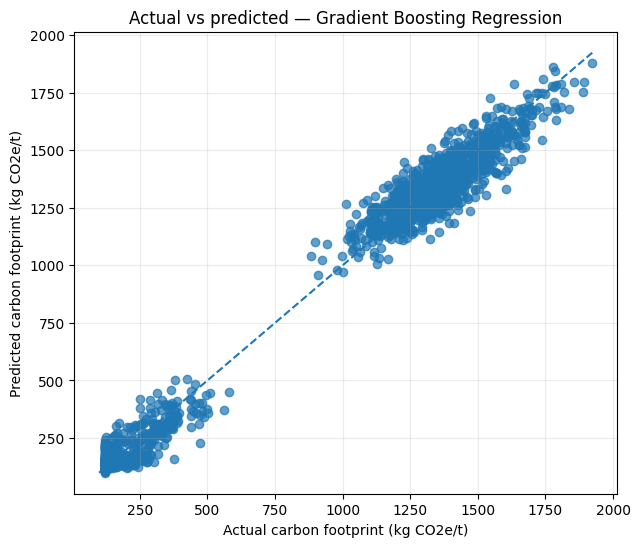

In [30]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.7)

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual carbon footprint (kg CO2e/t)")
plt.ylabel("Predicted carbon footprint (kg CO2e/t)")
plt.title(f"Actual vs predicted — {best_model_name}")
plt.grid(alpha=0.25)
plt.show()


## 9. Prediction errors


### How to understand the residual chart

A residual is calculated as:

`actual carbon footprint - predicted carbon footprint`

- Residual close to **0**: prediction is accurate.
- Positive residual: the model predicted too low.
- Negative residual: the model predicted too high.
- Large distance from zero: large prediction error.

A good residual plot should look like a roughly random cloud around the zero line. A visible curve, funnel shape, or clusters would suggest that the model is missing a pattern or behaves differently for certain ranges.


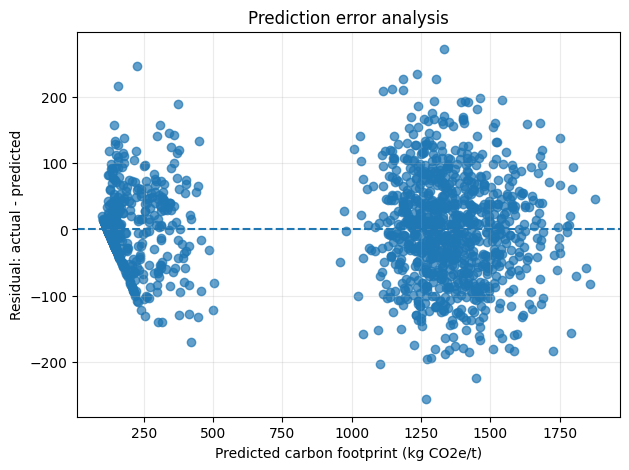

In [31]:
residuals = y_test.to_numpy() - best_predictions

plt.figure(figsize=(7, 5))
plt.scatter(best_predictions, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted carbon footprint (kg CO2e/t)")
plt.ylabel("Residual: actual - predicted")
plt.title("Prediction error analysis")
plt.grid(alpha=0.25)
plt.show()


## 10. Feature importance

Feature importance is shown using the Random Forest model because it provides direct importance values.


### How to understand feature importance

Feature importance shows which inputs the Random Forest used most when separating low- and high-carbon batches.

An importance value is a **relative contribution**, not a physical unit and not proof of causation. The values approximately sum to 1 across all encoded features.

For example:

- `technology_route_BF-BOF = 0.443` means the BF-BOF route accounts for about **44.3% of the model's total split importance**.
- `technology_route_EAF = 0.264` contributes about **26.4%**.
- `energy_consumption_kwh_per_tonne = 0.261` contributes about **26.1%**.

These three dominate because the synthetic carbon-footprint formula was designed to depend strongly on production route and energy consumption.

Important: this graph says **what the model relied on**, not that changing a feature by 1% will reduce emissions by the same importance percentage.


,feature,importance
21,categorical__technology_route_BF-BOF,0.442855
22,categorical__technology_route_EAF,0.264412
4,numeric__energy_consumption_kwh_per_tonne,0.260924
8,numeric__chromium_pct,0.015845
3,numeric__renewable_energy_pct,0.005106
2,numeric__recycled_content_pct,0.002836
14,categorical__product_type_Stainless Steel,0.001512
13,categorical__product_type_Hot Rolled Coil,0.001155
5,numeric__scrap_quality_score,0.000785
15,categorical__product_type_Wire Rod,0.000563


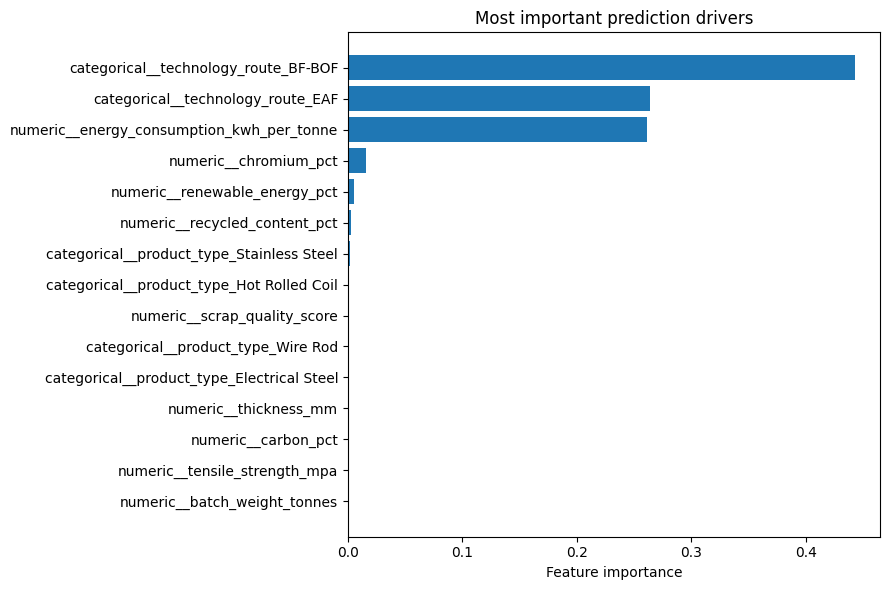

In [32]:
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": feature_importances
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

display(importance_df)

plt.figure(figsize=(9, 6))
plt.barh(
    importance_df["feature"].iloc[::-1],
    importance_df["importance"].iloc[::-1]
)
plt.xlabel("Feature importance")
plt.title("Most important prediction drivers")
plt.tight_layout()
plt.show()


## 11. Batch-level prediction table


### How to read the batch-level table

Each row represents one test batch.

- `actual_carbon_footprint`: the known synthetic value.
- `predicted_carbon_footprint`: the model's estimate.
- `absolute_error`: the size of the mistake without considering direction.

For example, if the actual value is 500 and the prediction is 460, the absolute error is 40 kg CO₂e/t. Sorting by predicted footprint helps identify batches that the model expects to have the largest emissions.


In [33]:
results = X_test.copy()

results["actual_carbon_footprint"] = y_test.to_numpy()
results["predicted_carbon_footprint"] = best_predictions
results["absolute_error"] = np.abs(
    results["actual_carbon_footprint"]
    - results["predicted_carbon_footprint"]
)

results = results.sort_values(
    "predicted_carbon_footprint",
    ascending=False
)

display(results.head(10))


,product_type,steel_grade,technology_route,country_of_origin,batch_weight_tonnes,thickness_mm,recycled_content_pct,renewable_energy_pct,energy_consumption_kwh_per_tonne,scrap_quality_score,carbon_pct,manganese_pct,chromium_pct,yield_strength_mpa,tensile_strength_mpa,actual_carbon_footprint,predicted_carbon_footprint,absolute_error
8069,Stainless Steel,DX51D,BF-BOF,Spain,26.87,21.78,16.69,9.66,2070.3,68.89,0.151,1.481,19.286,362.7,521.3,1923.2,1877.889402,45.310598
6838,Stainless Steel,S355JR,BF-BOF,Germany,13.02,19.35,9.00,12.18,2084.2,90.18,0.131,1.583,16.229,334.1,526.4,1776.7,1859.299749,82.599749
2145,Stainless Steel,M270-35A,BF-BOF,Germany,31.23,16.35,7.45,83.72,2240.3,78.83,0.187,0.946,17.442,328.2,478.3,1787.1,1845.204955,58.104955
1402,Stainless Steel,304,BF-BOF,Italy,30.84,11.13,11.79,15.31,1954.3,75.26,0.020,1.436,20.106,299.4,439.7,1739.8,1810.294967,70.494967
6681,Stainless Steel,S235JR,BF-BOF,Spain,18.59,1.69,26.51,7.89,2122.1,60.16,0.217,1.803,16.593,352.9,509.7,1891.1,1797.444863,93.655137
710,Stainless Steel,DX51D,BF-BOF,Spain,8.20,13.19,9.39,85.63,2209.0,63.49,0.146,0.462,18.743,304.0,437.8,1855.0,1794.647582,60.352418
5851,Stainless Steel,S235JR,BF-BOF,Germany,16.94,22.18,26.36,13.38,2032.7,86.71,0.238,1.719,18.243,368.3,461.1,1633.7,1789.336083,155.636083
9419,Stainless Steel,304,BF-BOF,Belgium,32.96,24.59,19.79,71.40,2209.7,58.50,0.136,2.005,19.729,328.7,532.0,1806.8,1786.809327,19.990673
1084,Stainless Steel,M270-35A,BF-BOF,Belgium,30.73,8.89,12.91,21.26,1974.1,80.04,0.207,0.776,17.208,280.6,443.9,1790.9,1784.496928,6.403072
852,Stainless Steel,DX51D,BF-BOF,Spain,23.87,22.22,13.13,51.47,2010.9,55.51,0.103,1.317,17.000,341.4,467.8,1773.2,1777.760563,4.560563


## 12. Scenario simulation

This compares a current steel batch with a more sustainable production scenario.


### What the scenario values mean

The two rows describe the **same hypothetical steel product**, but with different production conditions.

The improved scenario changes:

- recycled content from **65% to 85%**;
- renewable energy from **30% to 70%**;
- energy consumption from **720 to 610 kWh per tonne**;
- scrap-quality score from **80 to 92**.

All other variables remain unchanged. This is important because the comparison tries to isolate the predicted effect of these process improvements.

The model then predicts:

- Current process: **140.5 kg CO₂e/t**
- Improved process: **98.9 kg CO₂e/t**
- Estimated reduction: **41.6 kg CO₂e/t**
- Estimated percentage reduction: **29.6%**

The improved prediction becomes lower because the synthetic training data was generated so that lower energy use, more renewable energy, and better circularity-related inputs are associated with lower carbon footprint.

This is a **model-based scenario estimate**, not a verified life-cycle assessment and not proof that the exact reduction would occur in a real factory.


In [34]:
current_scenario = pd.DataFrame([{
    "product_type": "Hot Rolled Coil",
    "steel_grade": "S355JR",
    "technology_route": "EAF",
    "country_of_origin": "Germany",
    "batch_weight_tonnes": 25.0,
    "thickness_mm": 4.0,
    "recycled_content_pct": 65.0,
    "renewable_energy_pct": 30.0,
    "energy_consumption_kwh_per_tonne": 720.0,
    "scrap_quality_score": 80.0,
    "carbon_pct": 0.18,
    "manganese_pct": 1.25,
    "chromium_pct": 0.25,
    "yield_strength_mpa": 355.0,
    "tensile_strength_mpa": 510.0
}])

improved_scenario = current_scenario.copy()

improved_scenario["recycled_content_pct"] = 85.0
improved_scenario["renewable_energy_pct"] = 70.0
improved_scenario["energy_consumption_kwh_per_tonne"] = 610.0
improved_scenario["scrap_quality_score"] = 92.0

current_prediction = best_model.predict(current_scenario)[0]
improved_prediction = best_model.predict(improved_scenario)[0]

estimated_reduction = (
    current_prediction - improved_prediction
)

estimated_reduction_pct = (
    estimated_reduction / current_prediction * 100
)

scenario_results = pd.DataFrame({
    "Scenario": [
        "Current process",
        "Improved process"
    ],
    "Predicted carbon footprint kg CO2e/t": [
        current_prediction,
        improved_prediction
    ]
}).round(1)

display(scenario_results)

print(
    f"Estimated reduction: "
    f"{estimated_reduction:.1f} kg CO2e/t"
)

print(
    f"Estimated percentage reduction: "
    f"{estimated_reduction_pct:.1f}%"
)


,Scenario,Predicted carbon footprint kg CO2e/t
0,Current process,140.5
1,Improved process,98.9


Estimated reduction: 41.6 kg CO2e/t
Estimated percentage reduction: 29.6%


## 13. How this helps?

- Predict the likely carbon footprint of a batch before final verification.
- Compare different production routes and process conditions.
- Simulate changes in recycled content, renewable energy, and energy efficiency.
- Identify the variables most associated with carbon emissions.
- Flag suspicious cases when declared carbon footprint differs strongly from predicted values.
- Support procurement, sustainability reporting, and customer communication.
- Demonstrate how structured DPP data can support analytics rather than only compliance.

## Important limitation

This notebook demonstrates the analytical method using synthetic data.

A real industrial model would require:
- verified historical production data;
- an agreed product carbon-footprint calculation method;
- consistent system boundaries;
- process-expert validation;
- data governance and access controls.
